# Data Screening and Visualization
## EARTHLAB 2026 — Monday Afternoon Practical

**Instructor:** Alice Cicirello

**Developed by:** Francesco Muschitiello
**Last updated by:** Alice Cicirello (13/06/2026)



**Purpose:** Before we build any machine-learning model we need to *look at our data*.
This notebook walks through two datasets that we will use later in the week:

1. **Argo deep-current reconstruction** (tabular CSV data for an ANN practical)
2. **Arctic sea-ice classification** (image data for a CNN practical)

For each dataset we will:
- Load and inspect the data
- Check for missing values and anomalies
- Visualise distributions, spatial patterns, and correlations
- Identify potential issues that could affect model training

For better understanding the steps involved, check L1: Fundamentals of machine learning
> **Note:** This notebook uses only pandas, numpy, matplotlib, seaborn, and Pillow.
> We do *not* import PyTorch here — that comes in the modelling practicals.

## Setup and Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

print("All imports successful.")

from cartopy import config
import cartopy.crs as ccrs
import cartopy.feature as cfeature


All imports successful.


---
# PART 1 — Argo Deep-Current Reconstruction

The Argo programme deploys thousands of autonomous floats that profile the ocean's
temperature and salinity.  

From these profiles we can estimate large-scale ocean currents at depth. 

The dataset below contains gridded cells where each row
represents one spatial cell with:

| Column | Description |
|--------|-------------|
| `cell_id` | Unique cell identifier |
| `lat`, `lon` | Latitude and longitude of the cell centre |
| `obs_u` | Eastward current velocity (m/s) — **target** |
| `obs_v` | Northward current velocity (m/s) — **target** |
| `theta` | Potential temperature (°C) |
| `salt` | Salinity (g/kg) |
| `dT_dx`, `dT_dy` | Temperature gradients (°C / 100 km) |
| `dS_dx`, `dS_dy` | Salinity gradients (g/kg / 100 km) |
| `f_coriolis` | Coriolis parameter (1/s) |
| `n_cycles` | Number of Argo cycles contributing to this cell |

Our goal in the ANN practical (after L2) will be to predict `obs_u` and `obs_v` from the
other features.  

A subset of cells has been held out as "gaps" for evaluation.

### 1.1 Load the CSV files

In [3]:
# Paths relative to this notebook
ARGO_DIR = Path("../data/argo_current_reconstruction")

train = pd.read_csv(ARGO_DIR / "train.csv")
gaps   = pd.read_csv(ARGO_DIR / "gaps_to_predict.csv")
answers = pd.read_csv(ARGO_DIR / "gaps_answers.csv")

print(f"train.csv            : {train.shape[0]:>5} rows x {train.shape[1]} columns")
print(f"gaps_to_predict.csv  : {gaps.shape[0]:>5} rows x {gaps.shape[1]} columns")
print(f"gaps_answers.csv     : {answers.shape[0]:>5} rows x {answers.shape[1]} columns")

train.csv            :  5159 rows x 13 columns
gaps_to_predict.csv  :  2272 rows x 10 columns
gaps_answers.csv     :  2272 rows x 6 columns


In [4]:
train.head()

,cell_id,lat,lon,theta,salt,dT_dx,dT_dy,dS_dx,dS_dy,f_coriolis,obs_u,obs_v,n_cycles
0,0,-69.0,-179.0,1.0547,34.7201,0.03990,-0.01218,-0.00047,-0.00031,-0.000136,0.0123,0.0023,15
1,1,-67.0,-179.0,1.0310,34.7188,0.02851,0.04905,0.00128,0.00142,-0.000134,0.0484,-0.0258,33
2,2,-65.0,-179.0,1.5307,34.7291,0.08154,0.34278,0.00157,0.00387,-0.000132,0.0333,-0.0115,92
3,3,-63.0,-179.0,2.0863,34.7107,0.01318,0.13886,-0.00138,-0.02035,-0.000130,0.0292,-0.0082,133
4,4,-61.0,-179.0,2.2675,34.6608,-0.03655,0.06899,0.01428,-0.02632,-0.000128,0.0247,0.0241,157


In [5]:
gaps.head()

,cell_id,lat,lon,theta,salt,dT_dx,dT_dy,dS_dx,dS_dy,f_coriolis
0,14,-39.0,-179.0,5.7979,34.4110,-0.01490,-0.07510,-0.00816,-0.00669,-0.000092
1,15,-37.0,-179.0,5.6523,34.3995,-0.13348,-0.07006,-0.01381,-0.00651,-0.000088
2,16,-35.0,-179.0,5.4062,34.3807,-0.15431,-0.09240,-0.01104,-0.00530,-0.000084
3,24,-5.0,-179.0,4.5665,34.5416,0.00844,0.03565,0.00042,0.00276,-0.000013
4,26,-1.0,-179.0,4.5285,34.5520,-0.01002,0.02553,0.00051,0.00090,-0.000003


In [5]:
answers.head()

,cell_id,lat,lon,obs_u,obs_v,obs_speed
0,14,-39.0,-179.0,-0.0104,-0.0060,0.012007
1,15,-37.0,-179.0,-0.0049,0.0028,0.005644
2,16,-35.0,-179.0,-0.0074,-0.0079,0.010825
3,24,-5.0,-179.0,0.0219,-0.0010,0.021923
4,26,-1.0,-179.0,0.0198,0.0035,0.020107


### 1.2 Missing values and data types

Before doing anything else, check whether any values are missing and whether
pandas inferred the correct types.  Missing data in features would require
imputation; missing data in targets would reduce our effective training set.

In [6]:
print("=== Training set ===")
print(train.dtypes)
print()
print("Missing values per column:")
print(train.isnull().sum())

=== Training set ===
cell_id         int64
lat           float64
lon           float64
theta         float64
salt          float64
dT_dx         float64
dT_dy         float64
dS_dx         float64
dS_dy         float64
f_coriolis    float64
obs_u         float64
obs_v         float64
n_cycles        int64
dtype: object

Missing values per column:
cell_id       0
lat           0
lon           0
theta         0
salt          0
dT_dx         0
dT_dy         0
dS_dx         0
dS_dy         0
f_coriolis    0
obs_u         0
obs_v         0
n_cycles      0
dtype: int64


In [8]:
print("=== Gaps (inputs only) ===")
print(gaps.dtypes)
print()
print("Missing values per column:")
print(gaps.isnull().sum())

=== Gaps (inputs only) ===
cell_id         int64
lat           float64
lon           float64
theta         float64
salt          float64
dT_dx         float64
dT_dy         float64
dS_dx         float64
dS_dy         float64
f_coriolis    float64
dtype: object

Missing values per column:
cell_id       0
lat           0
lon           0
theta         0
salt          0
dT_dx         0
dT_dy         0
dS_dx         0
dS_dy         0
f_coriolis    0
dtype: int64


In [9]:
print("=== Gap answers ===")
print(answers.dtypes)
print()
print("Missing values per column:")
print(answers.isnull().sum())

=== Gap answers ===
cell_id        int64
lat          float64
lon          float64
obs_u        float64
obs_v        float64
obs_speed    float64
dtype: object

Missing values per column:
cell_id      0
lat          0
lon          0
obs_u        0
obs_v        0
obs_speed    0
dtype: int64


### 1.3 Summary statistics

`describe()` gives us a quick overview of each feature's range, mean, and
spread.  Look out for:
- Extreme min/max values that might indicate outliers or data errors
- Very different scales across features (may need normalisation)
- Skewed distributions (compare mean vs. 50th percentile)

In [10]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
cell_id,5159.0,3705.733669,2147.065486,0.000000,1845.500000,3677.000000,5558.500000,7430.000000
lat,5159.0,-13.256251,35.553108,-75.000000,-43.000000,-17.000000,15.000000,79.000000
lon,5159.0,-15.866059,110.655352,-179.000000,-119.000000,-27.000000,81.000000,179.000000
theta,5159.0,4.105035,1.758095,-0.823800,3.195850,4.244400,4.816850,13.823400
salt,5159.0,34.579465,0.471182,22.269100,34.393700,34.534700,34.698000,38.770400
dT_dx,5159.0,0.007767,0.090181,-1.070560,-0.018215,0.000580,0.017300,0.985060
dT_dy,5159.0,0.038024,0.152732,-1.760740,-0.027635,0.017000,0.080795,1.438450
dS_dx,5159.0,0.000893,0.010866,-0.117680,-0.001490,0.000250,0.002430,0.112150
dS_dy,5159.0,-0.000959,0.019574,-0.137280,-0.004460,0.001000,0.006990,0.110440
f_coriolis,5159.0,-0.000029,0.000079,-0.000141,-0.000099,-0.000043,0.000038,0.000143


### 1.4 Distribution of each feature (histograms)

Plotting histograms for every numeric feature lets us spot skewness, multi-modal
distributions, and potential outliers at a glance.

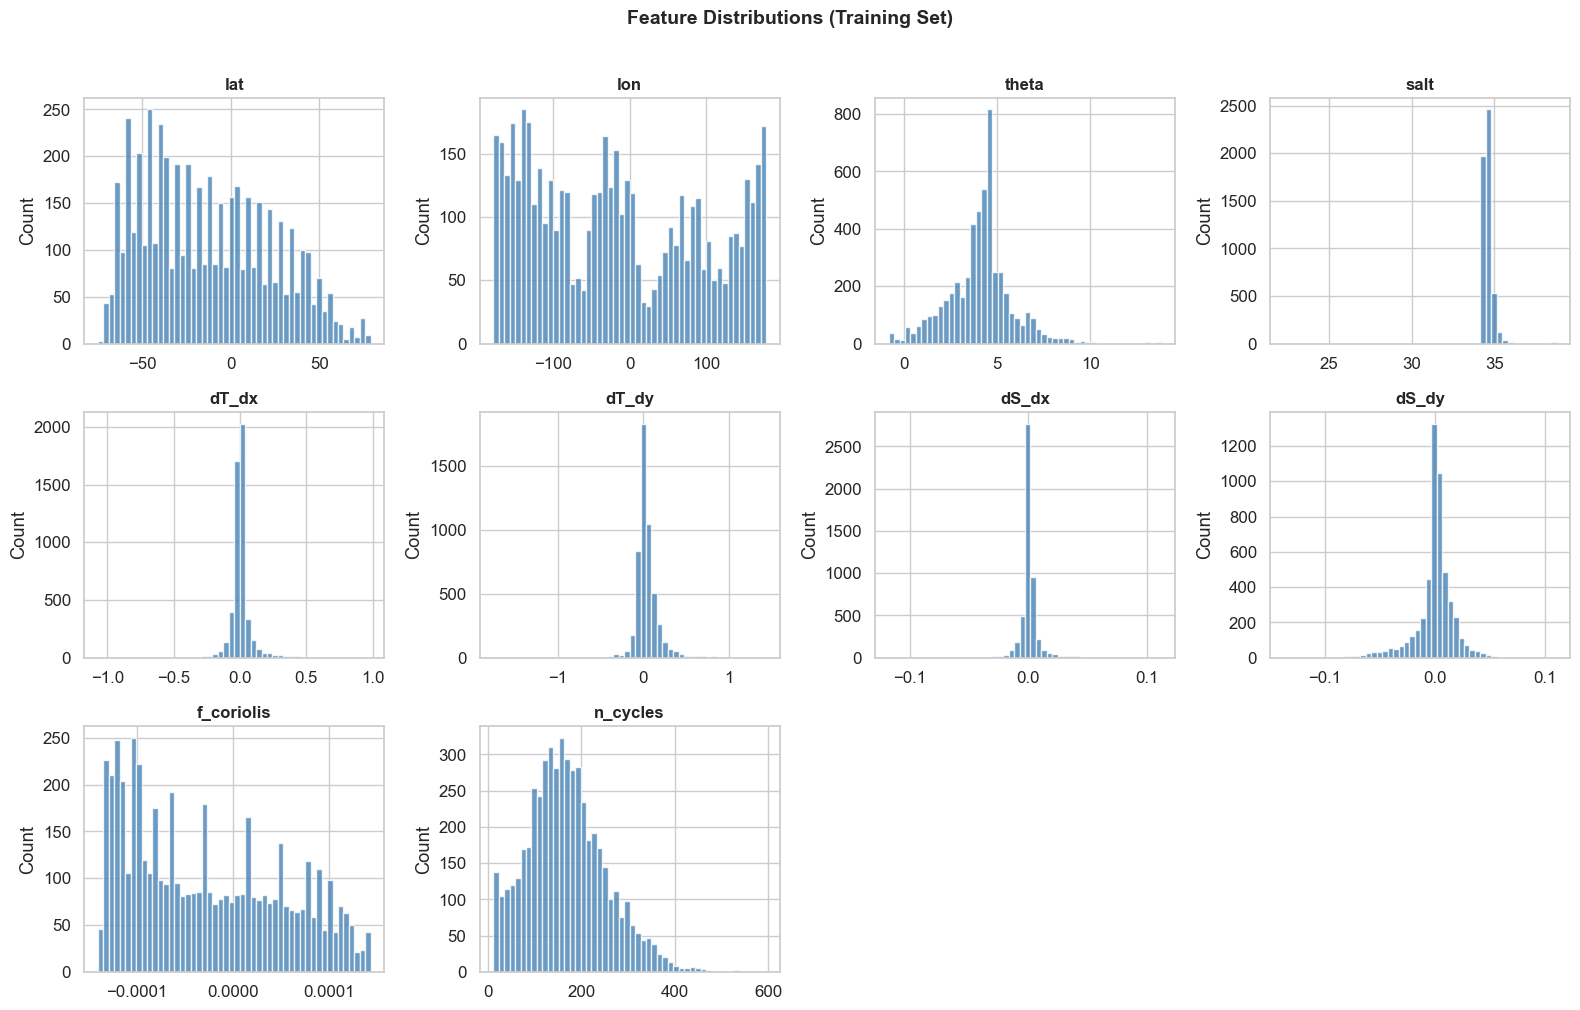

In [11]:
feature_cols = [c for c in train.columns if c not in ("cell_id", "obs_u", "obs_v")]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.hist(train[col].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")

# Hide any unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions (Training Set)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1.5 Distribution of target variables

The two target variables are `obs_u` (eastward) and `obs_v` (northward) current
velocities.  Let us check whether they are roughly symmetric around zero (as we
might expect for large-scale ocean currents) and whether any extreme values
stand out.

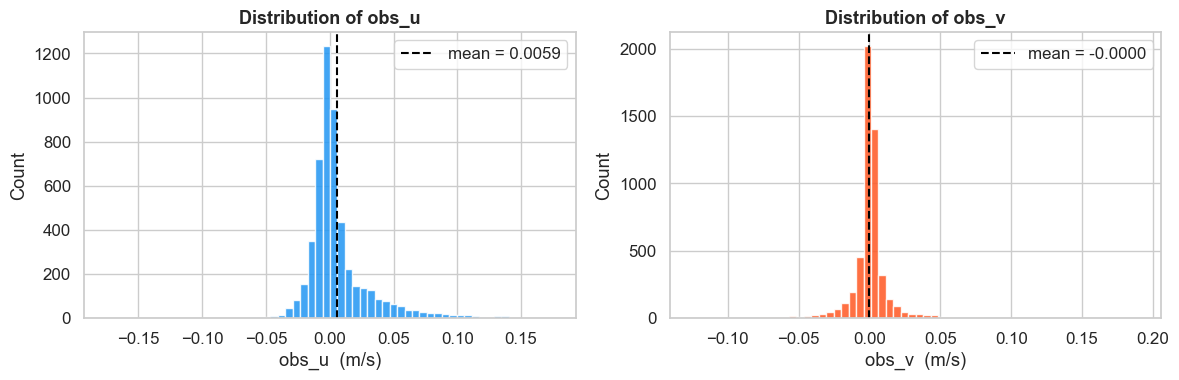

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, colour in zip(axes, ["obs_u", "obs_v"], ["#2196F3", "#FF5722"]):
    ax.hist(train[col].dropna(), bins=60, color=colour, edgecolor="white", alpha=0.85)
    ax.axvline(train[col].mean(), color="black", ls="--", lw=1.5, label=f"mean = {train[col].mean():.4f}")
    ax.set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"{col}  (m/s)")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 Scatter plot: obs_u vs obs_v

Plotting the two velocity components against each other, coloured by current
speed, reveals the joint distribution.  Are the two components correlated?  Is
there a dominant current direction?

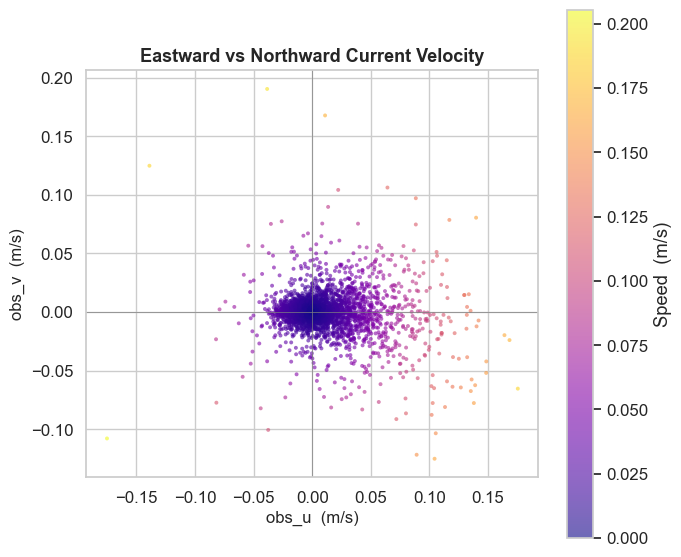

In [15]:
train["obs_speed"] = np.sqrt(train["obs_u"]**2 + train["obs_v"]**2)

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(
    train["obs_u"], train["obs_v"],
    c=train["obs_speed"], cmap="plasma", s=8, alpha=0.6, edgecolors="none"
)
ax.set_xlabel("obs_u  (m/s)", fontsize=12)
ax.set_ylabel("obs_v  (m/s)", fontsize=12)
ax.set_title("Eastward vs Northward Current Velocity", fontsize=13, fontweight="bold")
ax.set_aspect("equal")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Speed  (m/s)")
plt.tight_layout()
plt.show()

### 1.7 Spatial map of training data

Where in the ocean are our training cells?  Colour by current speed to see which
regions have strong currents (e.g., western boundary currents like the Gulf Stream
or Kuroshio).

C:\Users\ac685\anaconda3\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


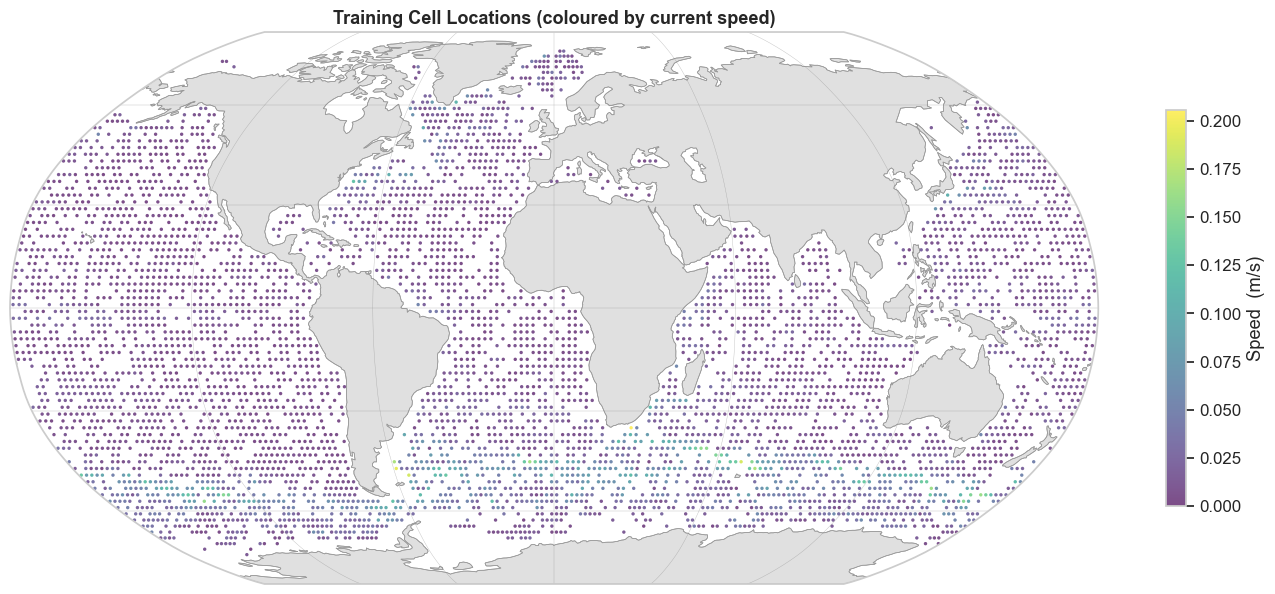

In [13]:
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor='#e0e0e0', edgecolor='#999999', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#999999')
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

sc = ax.scatter(
    train["lon"], train["lat"],
    c=train["obs_speed"], cmap="viridis", s=6, alpha=0.7, edgecolors="none",
    transform=ccrs.PlateCarree()
)
ax.set_title("Training Cell Locations (coloured by current speed)", fontsize=13, fontweight="bold")
cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Speed  (m/s)")
plt.tight_layout()
plt.show()


### 1.8 Correlation heatmap

A correlation matrix shows us which features are linearly related to each other
and — importantly — which features correlate most strongly with our targets.
High inter-feature correlations may also indicate redundancy.

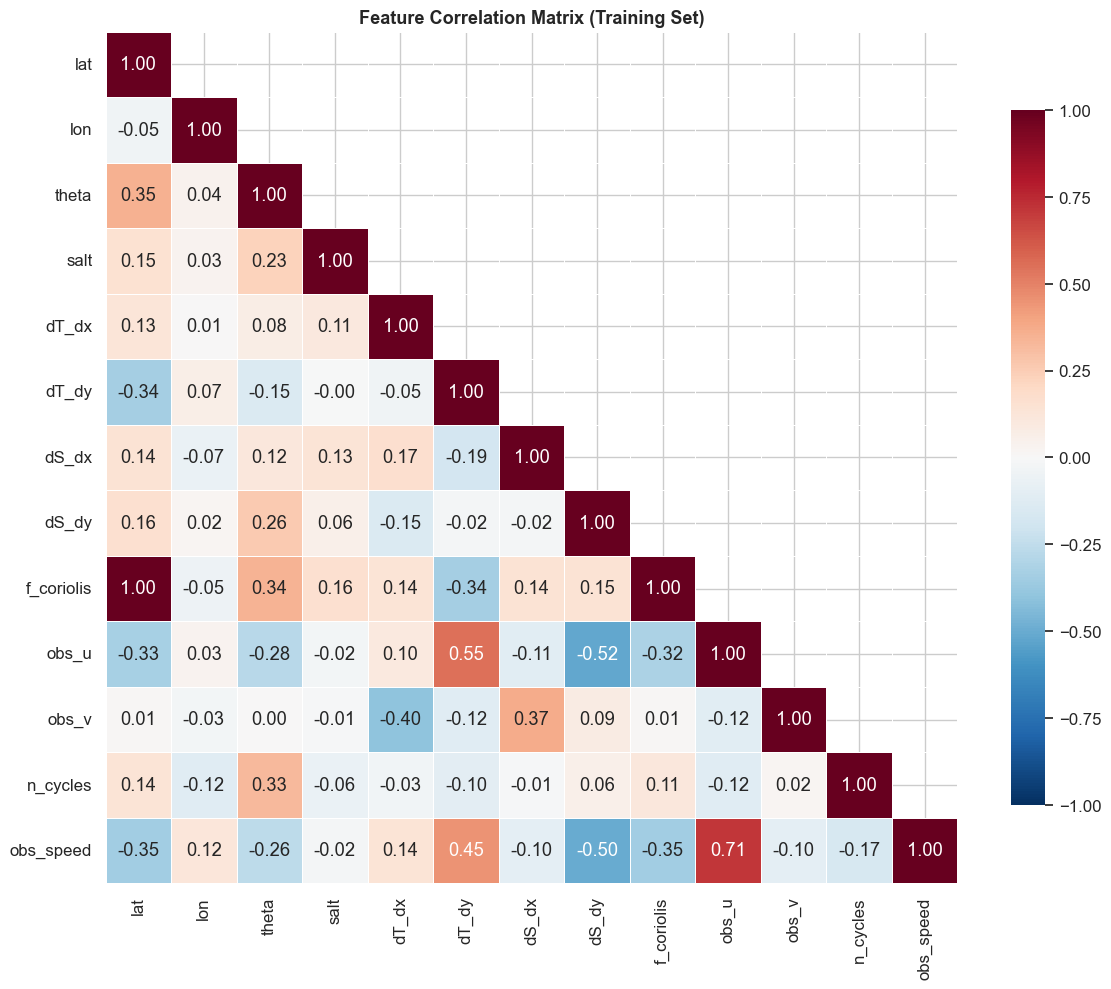

In [16]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# Exclude cell_id from correlation (it is just an identifier)
numeric_cols = [c for c in numeric_cols if c != "cell_id"]
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlation Matrix (Training Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.9 Training data vs held-out gaps

The ANN must predict currents in the "gap" cells where velocities are unknown.
Let us visualise where these gap cells are relative to the training cells.
Ideally, gaps should be *spatially interspersed* among training data, not
concentrated in a single region (which would make the task much harder).

C:\Users\ac685\anaconda3\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


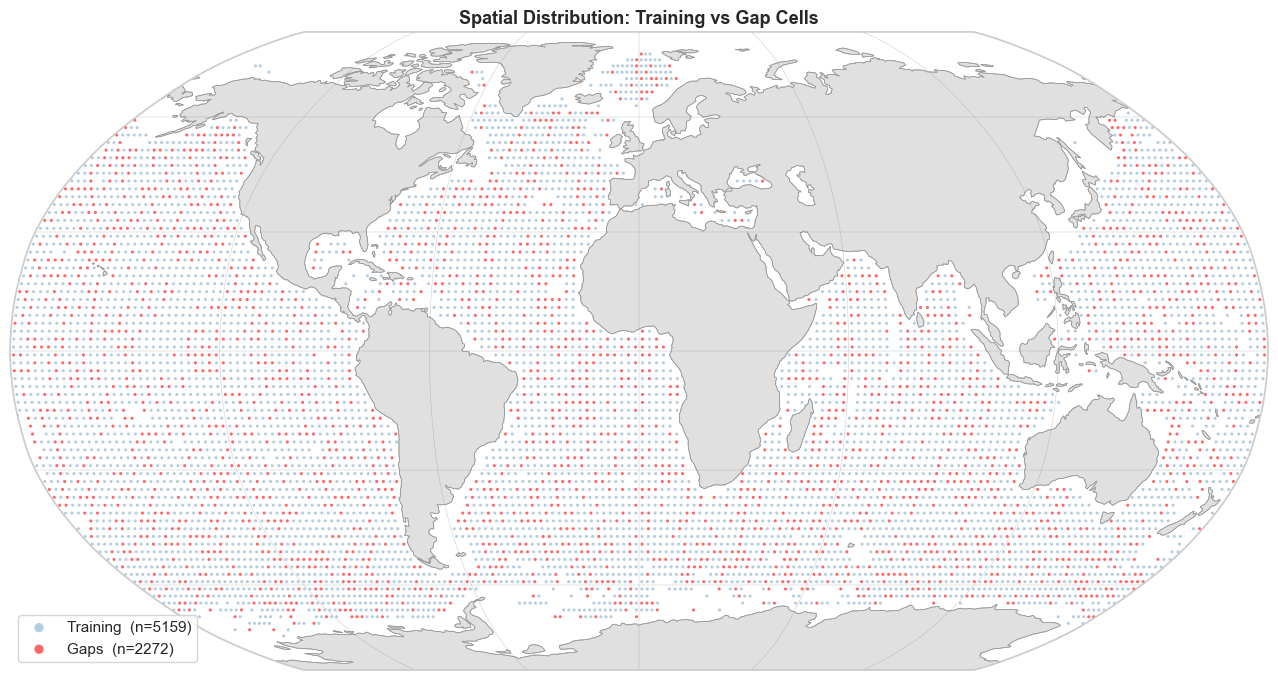

In [17]:
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor='#e0e0e0', edgecolor='#999999', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#999999')
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

ax.scatter(
    train["lon"], train["lat"],
    c="steelblue", s=5, alpha=0.4, label=f"Training  (n={len(train)})", edgecolors="none",
    transform=ccrs.PlateCarree()
)
ax.scatter(
    gaps["lon"], gaps["lat"],
    c="red", s=5, alpha=0.6, label=f"Gaps  (n={len(gaps)})", edgecolors="none",
    transform=ccrs.PlateCarree()
)
ax.set_title("Spatial Distribution: Training vs Gap Cells", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, markerscale=3, loc='lower left')
plt.tight_layout()
plt.show()


### 1.10 Data quality notes and things to watch for

**Key observations from our screening:**

1. **Missing values** — Check the output above. Any NaNs should be handled
   (imputation or removal) before training.

2. **Feature scales** — The features span very different ranges (e.g., temperature
   in °C vs Coriolis parameter of order 10$^{-5}$). We will need to **normalise
   or standardise** features before training an ANN.

3. **Target distribution** — Both `obs_u` and `obs_v` are approximately centred
   around zero but may have long tails. Consider whether outlier clipping or
   robust scaling is appropriate.

4. **Correlated features** — Some features are strongly correlated (e.g.,
   temperature and salinity gradients). This is fine for a neural network but
   worth noting.

5. **Spatial coverage** — Are the gap cells well-mixed among training cells, or
   are there regions with no nearby training data?  The ANN's ability to
   extrapolate to unseen spatial patterns will be limited.

6. **`n_cycles`** — Cells with very few Argo cycles may have noisier estimates.
   Think about whether to use this as a feature or as a quality filter.

---
# PART 2 — Arctic Sea-Ice Classification

Satellite radar imagery of the Arctic can be used to classify surface type into
three categories:

| Class | Description | Pixel appearance |
|-------|-------------|-----------------|
| `ice` | Consolidated sea ice | Bright (high concentration) |
| `open_water` | Open ocean | Dark (near zero concentration) |
| `miz` | Marginal ice zone | Mixed — the "hard" class |

Each image is a 128 x 128 pixel grayscale PNG where the pixel value represents
ice concentration (0 = open water, 255 = full ice cover).

The dataset is organised in **PyTorch ImageFolder** format:

```
sea_ice_dataset/
    train/          (4800 images: 1600 per class)
        ice/
        miz/
        open_water/
    test/           (1200 images: 400 per class)
    test_2019/      (1800 images: 600 per class)
    test_2024/      (1800 images: 600 per class)
```

The separate `test_2019` and `test_2024` splits let us study how model
performance changes when the test data comes from a different year — a common
form of **distribution shift** in climate applications.

### 2.1 Count images per class per split

In [18]:
ICE_DIR = Path("../data/sea_ice_dataset")

splits = ["train", "test", "test_2019", "test_2024"]
classes = ["ice", "miz", "open_water"]

counts = {}
for split in splits:
    counts[split] = {}
    for cls in classes:
        folder = ICE_DIR / split / cls
        if folder.exists():
            n = len(list(folder.glob("*.png")))
            counts[split][cls] = n
        else:
            counts[split][cls] = 0

count_df = pd.DataFrame(counts).T
count_df["total"] = count_df.sum(axis=1)
print(count_df.to_string())
print(f"\nGrand total: {count_df['total'].sum()} images")

            ice   miz  open_water  total
train      1600  1600        1600   4800
test        400   400         400   1200
test_2019   600   600         600   1800
test_2024   600   600         600   1800

Grand total: 9600 images


### 2.2 Sample images from each class

Let us display a 3 x 5 grid: one row per class, five random examples each.
This gives us an immediate sense of what the network "sees".

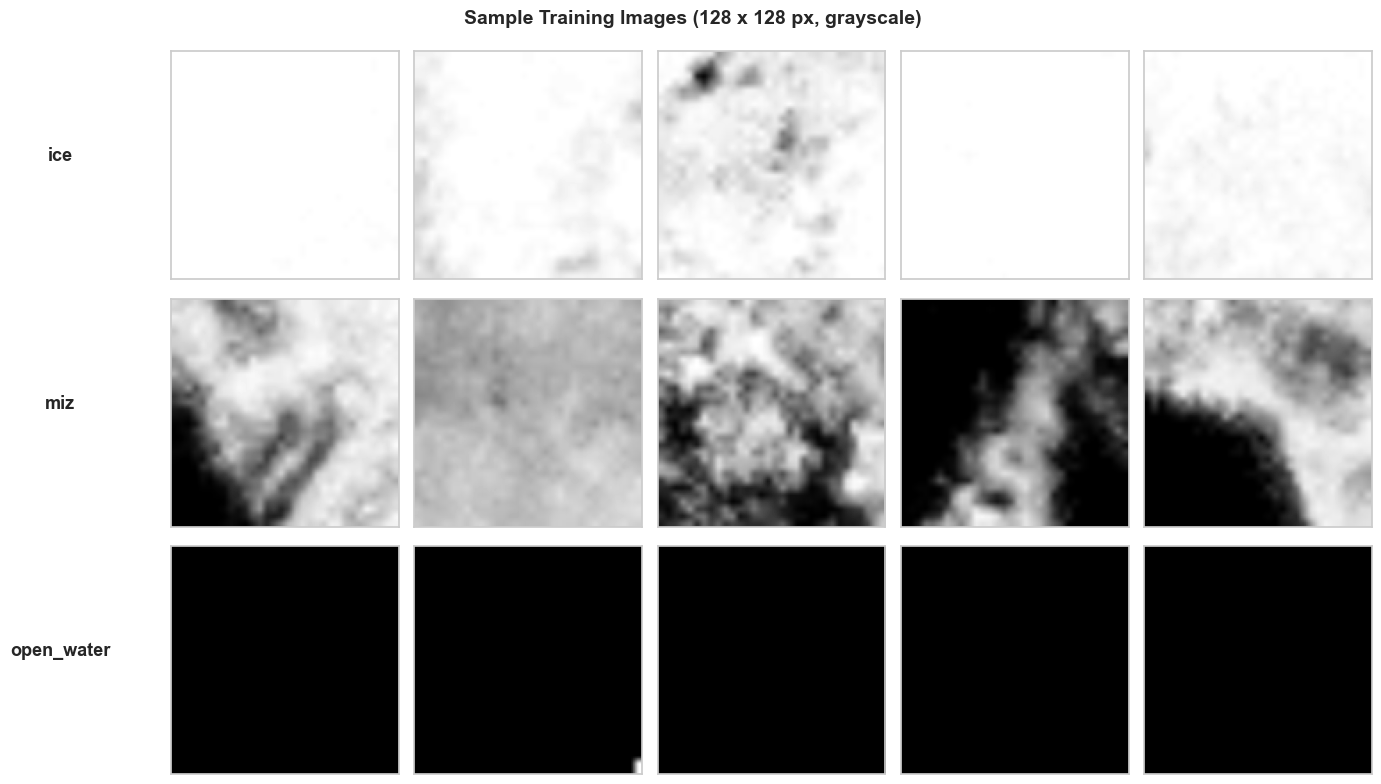

In [19]:
np.random.seed(42)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))

for row, cls in enumerate(classes):
    folder = ICE_DIR / "train" / cls
    all_imgs = sorted(folder.glob("*.png"))
    chosen = np.random.choice(len(all_imgs), size=5, replace=False)

    for col, idx in enumerate(chosen):
        img = np.array(Image.open(all_imgs[idx]))
        ax = axes[row, col]
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cls, fontsize=13, fontweight="bold", rotation=0, labelpad=80)

fig.suptitle("Sample Training Images (128 x 128 px, grayscale)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Pixel intensity distributions per class

By plotting histograms of pixel values we can see how well-separated the classes
are in raw intensity space.  If open water is consistently dark and ice is
consistently bright, simple thresholding might work for those two — but the
marginal ice zone (miz) is likely to overlap with both.

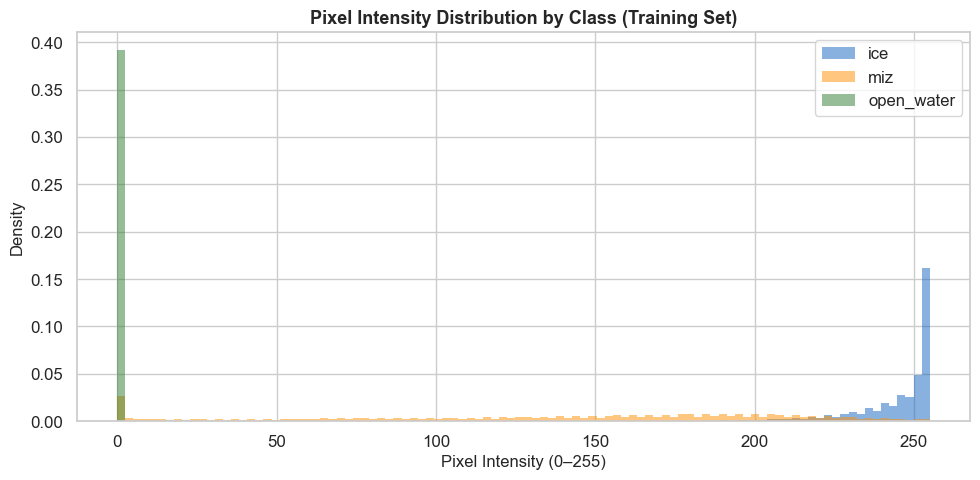

In [19]:
np.random.seed(123)
N_SAMPLE = 200  # images per class to keep this fast

fig, ax = plt.subplots(figsize=(10, 5))
colours = {"ice": "#1565C0", "miz": "#FF8F00", "open_water": "#2E7D32"}

for cls in classes:
    folder = ICE_DIR / "train" / cls
    all_imgs = sorted(folder.glob("*.png"))
    chosen = np.random.choice(len(all_imgs), size=min(N_SAMPLE, len(all_imgs)), replace=False)
    pixels = []
    for idx in chosen:
        img = np.array(Image.open(all_imgs[idx])).flatten()
        pixels.append(img)
    pixels = np.concatenate(pixels)
    ax.hist(pixels, bins=100, range=(0, 255), density=True,
            alpha=0.5, color=colours[cls], label=cls, edgecolor="none")

ax.set_xlabel("Pixel Intensity (0–255)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Pixel Intensity Distribution by Class (Training Set)", fontsize=13, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 2.4 Mean image per class

Averaging many images reveals the *typical* appearance of each class.  A sharp
mean image means the class is consistent; a blurry, uniform mean suggests high
variability.

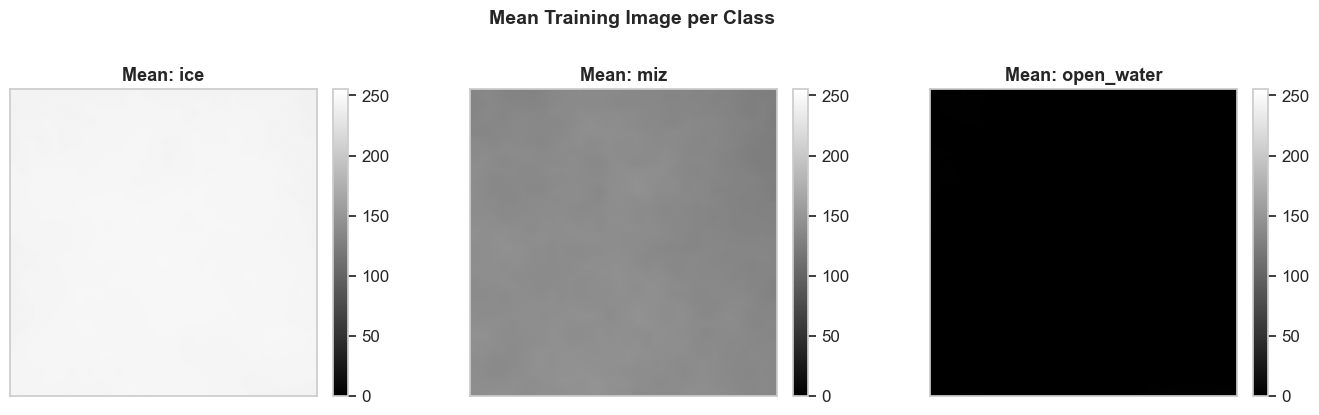

In [20]:
np.random.seed(99)
N_MEAN = 400  # images per class

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, cls in zip(axes, classes):
    folder = ICE_DIR / "train" / cls
    all_imgs = sorted(folder.glob("*.png"))
    chosen = np.random.choice(len(all_imgs), size=min(N_MEAN, len(all_imgs)), replace=False)
    stack = np.stack([np.array(Image.open(all_imgs[i]), dtype=np.float32) for i in chosen])
    mean_img = stack.mean(axis=0)

    im = ax.imshow(mean_img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Mean: {cls}", fontsize=13, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Mean Training Image per Class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Class difficulty: open_water vs miz

Let us quantify how "easy" each class is by looking at the spread of mean pixel
intensities per image.  Open water images should cluster tightly at low values;
ice images at high values; and miz images should show the widest spread,
confirming it is the hardest class to classify.

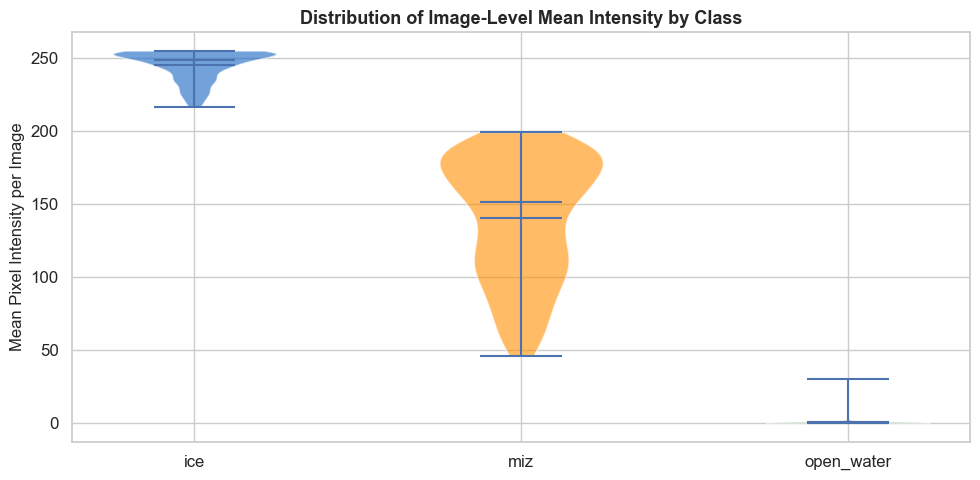

         ice:  mean =  244.9,  std =  10.4,  range = [216, 255]
         miz:  mean =  140.1,  std =  42.1,  range = [46, 199]
  open_water:  mean =    0.3,  std =   2.5,  range = [0, 30]


In [21]:
np.random.seed(77)
N_CHECK = 400

per_image_means = {}
for cls in classes:
    folder = ICE_DIR / "train" / cls
    all_imgs = sorted(folder.glob("*.png"))
    chosen = np.random.choice(len(all_imgs), size=min(N_CHECK, len(all_imgs)), replace=False)
    means = [np.array(Image.open(all_imgs[i])).mean() for i in chosen]
    per_image_means[cls] = means

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(classes))
bp_data = [per_image_means[cls] for cls in classes]

parts = ax.violinplot(bp_data, positions=positions, showmeans=True, showmedians=True)
colours_list = ["#1565C0", "#FF8F00", "#2E7D32"]
for pc, colour in zip(parts["bodies"], colours_list):
    pc.set_facecolor(colour)
    pc.set_alpha(0.6)

ax.set_xticks(positions)
ax.set_xticklabels(classes, fontsize=12)
ax.set_ylabel("Mean Pixel Intensity per Image", fontsize=12)
ax.set_title("Distribution of Image-Level Mean Intensity by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary
for cls in classes:
    vals = per_image_means[cls]
    print(f"{cls:>12s}:  mean = {np.mean(vals):6.1f},  std = {np.std(vals):5.1f},  "
          f"range = [{np.min(vals):.0f}, {np.max(vals):.0f}]")

**Observation:** Open water images are nearly uniformly dark (low intensity,
tight distribution), making them the "easy" class.  Ice images are consistently
bright.  The marginal ice zone (miz) spans a wide range of intermediate
intensities, confirming that it is the most challenging class for a classifier.

### 2.6 Distribution shift across test years

The dataset includes test sets from **2019** and **2024** in addition to the
standard test split.  Sea-ice conditions change from year to year due to climate
variability, so a model trained on one period may perform differently on another.

Let us compare pixel intensity distributions across the three test splits to see
if there is a visible shift.

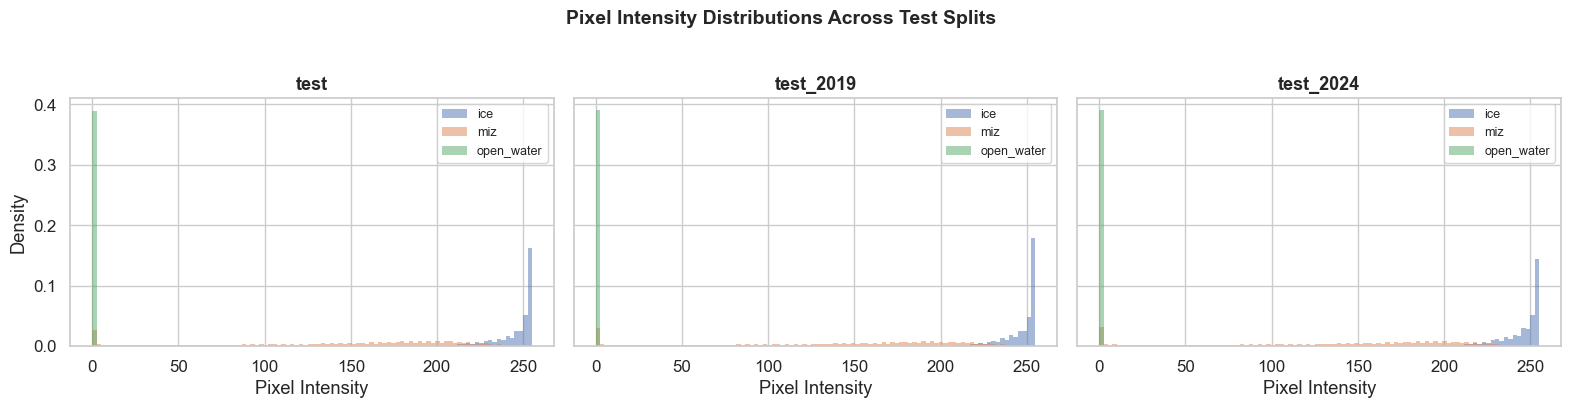

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
test_splits = ["test", "test_2019", "test_2024"]
colours_split = ["#5C6BC0", "#26A69A", "#EF5350"]

np.random.seed(55)

for ax, split, col in zip(axes, test_splits, colours_split):
    for cls in classes:
        folder = ICE_DIR / split / cls
        if not folder.exists():
            continue
        all_imgs = sorted(folder.glob("*.png"))
        chosen = np.random.choice(len(all_imgs), size=min(150, len(all_imgs)), replace=False)
        pixels = np.concatenate([np.array(Image.open(all_imgs[i])).flatten() for i in chosen])
        ax.hist(pixels, bins=100, range=(0, 255), density=True,
                alpha=0.5, label=cls, edgecolor="none")
    ax.set_title(split, fontsize=13, fontweight="bold")
    ax.set_xlabel("Pixel Intensity")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
fig.suptitle("Pixel Intensity Distributions Across Test Splits", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Discussion:**

- **Distribution shift** is one of the main challenges in deploying ML models for
  climate applications.  Arctic sea ice has been declining and changing character
  over recent decades, so a model trained on data from one period may not
  generalise well to another.

- Compare the histograms above: do the intensity distributions shift between
  `test`, `test_2019`, and `test_2024`?  Do some classes change more than others?

- In the CNN practical later this week, we will measure how classification
  accuracy changes across these splits and discuss strategies for building more
  robust models (data augmentation, domain adaptation, etc.).

---
# Summary

In this notebook we have:

1. **Loaded and inspected** both datasets (tabular and image)
2. **Checked for missing values** and verified data types
3. **Visualised distributions** of features, targets, and pixel intensities
4. **Examined spatial patterns** in the Argo current data
5. **Compared class separability** in the sea-ice images
6. **Identified potential challenges** (feature scaling, gap coverage, miz
   difficulty, distribution shift across years)

These observations will guide our choices when we set up the ANN and CNN models
in the practicals later this week.

---
*EARTHLAB 2026 — Data Screening and Visualization*
*Alice Cicirello*